In [13]:
import tensorflow as tf
from tensorflow import keras 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"Версия TensorFlow: {tf.__version__}")
print(f"Версия Keras: {keras.__version__}")

Версия TensorFlow: 2.21.0
Версия Keras: 3.15.1


In [3]:
X_dummy = np.array([[1.0, 2.0, 3.0], 
                    [4.0, 5.0, 6.0], 
                    [7.0, 8.0, 9.0], 
                    [10.0, 11.0, 12.0]], dtype=np.float32)

simple_layer = keras.layers.Dense(units=2, activation="relu", input_shape=[3])

output = simple_layer(X_dummy)

print("\n--- Проверка внутренней структуры нейронов ---")
weights, biases = simple_layer.get_weights()
print(f"Матрица весов W (размерность {weights.shape}):\n", weights)
print(f"Вектор смещений b (размерность {biases.shape}):\n", biases)
print(f"\nВыходной сигнал после функции активации ReLu:\n", output.numpy())



--- Проверка внутренней структуры нейронов ---
Матрица весов W (размерность (3, 2)):
 [[ 0.9318814  -0.22091967]
 [-0.3772276   0.40337062]
 [-0.4839759  -0.23861581]]
Вектор смещений b (размерность (2,)):
 [0. 0.]

Выходной сигнал после функции активации ReLu:
 [[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]


In [5]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

class_names = ["Футболка", "Брюки", "Пуловер", "Платье", "Пальто",
               "Сандалии", "Рубашка", "Кроссовки", "Сумка", "Ботильоны"]

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape = [28, 28]),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

print('Обучение модели...')
history = model.fit(X_train, y_train, epochs = 5, validation_data=(X_valid, y_valid))

/usr/lib/python3.14/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Обучение модели...
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7688 - loss: 0.7057 - val_accuracy: 0.8312 - val_loss: 0.5019
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8321 - loss: 0.4824 - val_accuracy: 0.8354 - val_loss: 0.4784
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8459 - loss: 0.4386 - val_accuracy: 0.8446 - val_loss: 0.4502
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8559 - loss: 0.4116 - val_accuracy: 0.8628 - val_loss: 0.3962
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8616 - loss: 0.3926 - val_accuracy: 0.8712 - val_loss: 0.3760


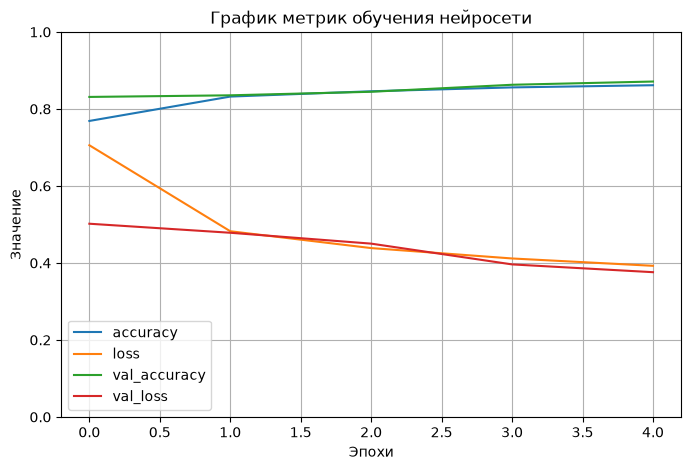

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

Матрица вероятностей для 3-х картинок (результат Softmax):
 [[0.   0.   0.   0.   0.   0.06 0.   0.09 0.   0.85]
 [0.   0.   0.97 0.   0.   0.   0.03 0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.  ]]

Предсказанные классы (индексы): [9 2 1]
Предсказанные названия: ['Ботильоны', 'Пуловер', 'Брюки']


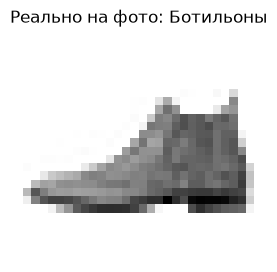

In [12]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.title("График метрик обучения нейросети")
plt.xlabel("Эпохи")
plt.ylabel("Значение")
plt.show()

X_new = X_test[:3]

y_proba = model.predict(X_new)
print("\nМатрица вероятностей для 3-х картинок (результат Softmax):\n", y_proba.round(2))

y_pred = np.argmax(y_proba, axis=1)
print(f"\nПредсказанные классы (индексы): {y_pred}")
print(f"Предсказанные названия: {[class_names[idx] for idx in y_pred]}")

plt.figure(figsize=(3, 3))
plt.imshow(X_new[0], cmap="binary")
plt.title(f"Реально на фото: {class_names[y_test[0]]}")
plt.axis("off")
plt.show()

In [14]:
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

model_reg = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(1)
])

model_reg.compile(loss="mean_squared_error", optimizer="sgd")

print("Запуск обучения регрессионной нейросети...")
history_reg = model_reg.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

mse_test = model_reg.evaluate(X_test, y_test)
print(f"\nФинальная ошибка MSE на тестовых данных: {mse_test:.4f}")

Запуск обучения регрессионной нейросети...
Epoch 1/10


/usr/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8897 - val_loss: 16.4752
Epoch 2/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7390 - val_loss: 6.7188
Epoch 3/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4756 - val_loss: 9.7981
Epoch 4/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4354 - val_loss: 7.7116
Epoch 5/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4284 - val_loss: 0.9122
Epoch 6/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3967 - val_loss: 0.3990
Epoch 7/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3858 - val_loss: 0.3689
Epoch 8/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3819 - val_loss: 0.3642
Epoch 9/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3785 - val_loss: 0.3780
Epoch 10/10
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3759 - val_loss: 0.3853
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3659

Финальная ошибка MSE на тестовых данных: 0.3659
